In [1]:
import cv2
import sys
import csv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
VIDEO_PATH         = '/content/TrafficVideo.mp4'        # Input video file
OUTPUT_VIDEO       = 'output_analytics.mp4'             # The final processed video with boxes/lines
OUTPUT_CSV         = 'traffic_data.csv'                 # The spreadsheet file where data is saved
RESIZE_TO          = (640, 360)                         # Shrink video to this size so it runs faster
FPS_ASSUMED        = 30

In [3]:
# Camera Geometry (Tuning where the AI looks)
IGNORE_TOP_FRAC    = 0.15   # Ignore the top 15% of the video (usually sky or distant trees)
COUNT_LINE_FRAC    = 0.25   # Place the counting line 25% down from the top of the screen
LINE_BUFFER        = 15     # The "Thickness" of the line. Cars must fully cross this to count.
WARMUP_FRAMES      = 200    # Give the AI 200 frames to memorize the empty road before counting begins


In [4]:
# AI Vision Sensitivity (How it detects blobs/cars)
MOG_HISTORY        = 200    # How many frames the AI uses to remember the background
MOG_VAR_THRESHOLD  = 16     # Sensitivity to changes (Lower = more sensitive to dark/distant cars)
MIN_CONTOUR_AREA   = 200

In [5]:
MAX_MATCH_DIST     = 80     # If a blob jumps more than 80 pixels in 1 frame, it's a new car
MAX_TRACK_AGE      = 10     # If the AI loses sight of a car, remember it for 10 frames before deleting
MIN_TRACK_HITS     = 5

In [6]:
class AdvancedTracker:
    def __init__(self, max_dist=80, max_age=10, min_hits=5):
        self.next_id      = 0    # The ID number given to the next new car we see
        self.tracks       = {}   # A memory dictionary storing all currently visible cars
        self.crossed_ids  = set() # A list of cars that have already been counted (prevents double counting)
        self.max_dist     = max_dist
        self.max_age      = max_age
        self.min_hits     = min_hits

        # Scoreboards
        self.entries      = 0   # Cars moving DOWN the screen
        self.exits        = 0   # Cars moving UP the screen
        self.completed_dwells = [] # A list keeping track of how long every car stayed on screen

    def get_zone_state(self, cy, line_y, buffer):
        """Checks if the car is currently ABOVE the line, BELOW the line, or INSIDE the line's thickness."""
        if cy < (line_y - buffer): return 'above'
        if cy > (line_y + buffer): return 'below'
        return 'inside_buffer'

    def update(self, centroids, line_y, current_frame):
        """This runs every single frame to connect old car positions to new car positions."""

        # 1. Update the age and stopwatch for cars we already know about
        for tid in list(self.tracks.keys()):
            self.tracks[tid]['age'] += 1

            # Calculate how long the car has been on screen (Dwell Time)
            dwell = current_frame - self.tracks[tid]['start_frame']
            if dwell > self.tracks[tid]['max_dwell']:
                self.tracks[tid]['max_dwell'] = dwell

            # If the car has been missing for too long, delete it and save its final time
            if self.tracks[tid]['age'] > self.max_age:
                if self.tracks[tid]['hits'] >= self.min_hits:
                    self.completed_dwells.append(self.tracks[tid]['max_dwell'])
                del self.tracks[tid]

        matched_track_ids = set()
        matched_cent_idxs = set()

        # 2. Try to match the newly detected blobs to our known cars
        for ci, (cx, cy) in enumerate(centroids):
            best_dist, best_tid = self.max_dist, -1

            # Find the closest known car ID to this new blob
            for tid, tr in self.tracks.items():
                if tid in matched_track_ids: continue

                # Math formula for distance between two points
                d = np.hypot(cx - tr['cx'], cy - tr['cy'])
                if d < best_dist:
                    best_dist, best_tid = d, tid

            # If we successfully matched a blob to a known car:
            if best_tid >= 0:
                prev_state = self.tracks[best_tid]['state']
                current_state = self.get_zone_state(cy, line_y, LINE_BUFFER)

                # Update the car's memory with its new position
                self.tracks[best_tid]['hits'] += 1
                self.tracks[best_tid].update({'cx': cx, 'cy': cy, 'age': 0})

                if current_state != 'inside_buffer':
                    self.tracks[best_tid]['state'] = current_state

                # 3. COUNTING LOGIC: Check if the car completely crossed the line
                # It must be a "mature" track (seen 5 times) and not counted yet
                if best_tid not in self.crossed_ids and self.tracks[best_tid]['hits'] >= self.min_hits:
                    new_state = self.tracks[best_tid]['state']

                    # Car went from completely above to completely below -> ENTRY
                    if prev_state == 'above' and new_state == 'below':
                        self.crossed_ids.add(best_tid)
                        self.entries += 1

                    # Car went from completely below to completely above -> EXIT
                    elif prev_state == 'below' and new_state == 'above':
                        self.crossed_ids.add(best_tid)
                        self.exits += 1

                matched_track_ids.add(best_tid)
                matched_cent_idxs.add(ci)

        # 4. If there are blobs left over that didn't match known cars, they are NEW cars!
        for ci, (cx, cy) in enumerate(centroids):
            if ci not in matched_cent_idxs:
                initial_state = self.get_zone_state(cy, line_y, LINE_BUFFER)
                self.tracks[self.next_id] = {
                    'cx': cx, 'cy': cy, 'age': 0, 'hits': 1,
                    'start_frame': current_frame, 'max_dwell': 0,
                    'state': initial_state
                }
                self.next_id += 1

    def draw(self, frame):
        """Draws colored dots and ID text on the cars."""
        for tid, tr in self.tracks.items():
            # Only draw the car if we are confident it's real (hits >= min_hits)
            if tr['hits'] >= self.min_hits:
                color = (int((tid*73)%255), int((tid*137)%255), int((tid*211)%255))
                cv2.circle(frame, (tr['cx'], tr['cy']), 5, color, -1)
                cv2.putText(frame, f"ID:{tid}", (tr['cx']+10, tr['cy']-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)


In [7]:
class AdvancedTracker:
    def __init__(self, max_dist=80, max_age=10, min_hits=5):
        self.next_id      = 0    # The ID number given to the next new car we see
        self.tracks       = {}   # A memory dictionary storing all currently visible cars
        self.crossed_ids  = set() # A list of cars that have already been counted (prevents double counting)
        self.max_dist     = max_dist
        self.max_age      = max_age
        self.min_hits     = min_hits

        # Scoreboards
        self.entries      = 0   # Cars moving DOWN the screen
        self.exits        = 0   # Cars moving UP the screen
        self.completed_dwells = [] # A list keeping track of how long every car stayed on screen

    def get_zone_state(self, cy, line_y, buffer):
        """Checks if the car is currently ABOVE the line, BELOW the line, or INSIDE the line's thickness."""
        if cy < (line_y - buffer): return 'above'
        if cy > (line_y + buffer): return 'below'
        return 'inside_buffer'

    def update(self, centroids, line_y, current_frame):
        """This runs every single frame to connect old car positions to new car positions."""

        # 1. Update the age and stopwatch for cars we already know about
        for tid in list(self.tracks.keys()):
            self.tracks[tid]['age'] += 1

            # Calculate how long the car has been on screen (Dwell Time)
            dwell = current_frame - self.tracks[tid]['start_frame']
            if dwell > self.tracks[tid]['max_dwell']:
                self.tracks[tid]['max_dwell'] = dwell

            # If the car has been missing for too long, delete it and save its final time
            if self.tracks[tid]['age'] > self.max_age:
                if self.tracks[tid]['hits'] >= self.min_hits:
                    self.completed_dwells.append(self.tracks[tid]['max_dwell'])
                del self.tracks[tid]

        matched_track_ids = set()
        matched_cent_idxs = set()

        # 2. Try to match the newly detected blobs to our known cars
        for ci, (cx, cy) in enumerate(centroids):
            best_dist, best_tid = self.max_dist, -1

            # Find the closest known car ID to this new blob
            for tid, tr in self.tracks.items():
                if tid in matched_track_ids: continue

                # Math formula for distance between two points
                d = np.hypot(cx - tr['cx'], cy - tr['cy'])
                if d < best_dist:
                    best_dist, best_tid = d, tid

            # If we successfully matched a blob to a known car:
            if best_tid >= 0:
                prev_state = self.tracks[best_tid]['state']
                current_state = self.get_zone_state(cy, line_y, LINE_BUFFER)

                # Update the car's memory with its new position
                self.tracks[best_tid]['hits'] += 1
                self.tracks[best_tid].update({'cx': cx, 'cy': cy, 'age': 0})

                if current_state != 'inside_buffer':
                    self.tracks[best_tid]['state'] = current_state

                # 3. COUNTING LOGIC: Check if the car completely crossed the line
                # It must be a "mature" track (seen 5 times) and not counted yet
                if best_tid not in self.crossed_ids and self.tracks[best_tid]['hits'] >= self.min_hits:
                    new_state = self.tracks[best_tid]['state']

                    # Car went from completely above to completely below -> ENTRY
                    if prev_state == 'above' and new_state == 'below':
                        self.crossed_ids.add(best_tid)
                        self.entries += 1

                    # Car went from completely below to completely above -> EXIT
                    elif prev_state == 'below' and new_state == 'above':
                        self.crossed_ids.add(best_tid)
                        self.exits += 1

                matched_track_ids.add(best_tid)
                matched_cent_idxs.add(ci)

        # 4. If there are blobs left over that didn't match known cars, they are NEW cars!
        for ci, (cx, cy) in enumerate(centroids):
            if ci not in matched_cent_idxs:
                initial_state = self.get_zone_state(cy, line_y, LINE_BUFFER)
                self.tracks[self.next_id] = {
                    'cx': cx, 'cy': cy, 'age': 0, 'hits': 1,
                    'start_frame': current_frame, 'max_dwell': 0,
                    'state': initial_state
                }
                self.next_id += 1

    def draw(self, frame):
        """Draws colored dots and ID text on the cars."""
        for tid, tr in self.tracks.items():
            # Only draw the car if we are confident it's real (hits >= min_hits)
            if tr['hits'] >= self.min_hits:
                color = (int((tid*73)%255), int((tid*137)%255), int((tid*211)%255))
                cv2.circle(frame, (tr['cx'], tr['cy']), 5, color, -1)
                cv2.putText(frame, f"ID:{tid}", (tr['cx']+10, tr['cy']-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)


In [8]:
mog = cv2.createBackgroundSubtractorMOG2(history=MOG_HISTORY, varThreshold=MOG_VAR_THRESHOLD, detectShadows=True)

# Create "digital glue" tools that connect broken pieces of cars back together
kernel_open  = cv2.getStructuringElement(cv2.MORPH_RECT, (5,  5))   # Erases tiny specs of noise
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))  # Glues car windshields and hoods together

def clean_mask(mask, ignore_height):
    """Takes the raw motion detection and cleans it up so the AI only sees solid white blobs."""
    mask[0:ignore_height, :] = 0  # Black out the sky/horizon so we don't track clouds

    # 1. Blur the image slightly to smooth jagged edges
    mask = cv2.medianBlur(mask, 5)
    # 2. Turn shadows (gray pixels) into pure black, leaving only solid objects
    _, mask = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)
    # 3. Apply the "digital glue" tools created above
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    return mask

In [9]:
if __name__ == "__main__":

    # Open the video file
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print(f"ERROR: Cannot open {VIDEO_PATH}. Check if the file is uploaded!")
        sys.exit()

    W, H = RESIZE_TO
    line_y = int(H * COUNT_LINE_FRAC)     # Convert the percentage into a pixel Y-coordinate
    ignore_h = int(H * IGNORE_TOP_FRAC)   # Convert the percentage into a pixel Y-coordinate

    # Turn on our tracker
    tracker = AdvancedTracker(max_dist=MAX_MATCH_DIST, max_age=MAX_TRACK_AGE, min_hits=MIN_TRACK_HITS)

    # Set up the file writers to save our final Video and final CSV Spreadsheet
    out = cv2.VideoWriter(OUTPUT_VIDEO, cv2.VideoWriter_fourcc(*'mp4v'), FPS_ASSUMED, RESIZE_TO)
    csv_file = open(OUTPUT_CSV, mode='w', newline='')
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(['Frame', 'Active_Objects', 'Total_Entries', 'Total_Exits'])

    # Variables to hold data while the video runs
    frame_count = 0
    obj_count_history = []
    heatmap_accum = np.zeros((H, W), dtype=np.float32) # A blank canvas to paint our traffic heatmap

    print("--- Video Analytics Pipeline Started ---")
    print("Processing video... (Live view disabled for maximum speed)")

    # Start reading the video like a flipbook, one frame at a time
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break # Stop when the video ends

        frame_count += 1
        frame = cv2.resize(frame, (W, H))
        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # Black and white is faster to process

        # A. Find Motion: Find moving pixels and clean them into solid blobs
        raw_mask = mog.apply(gray)
        mask     = clean_mask(raw_mask, ignore_h)

        # B. Heatmap: Everywhere a moving pixel is detected, add +1 to that spot on our canvas
        if frame_count > WARMUP_FRAMES:
            heatmap_accum[mask > 0] += 1

        # C. Object Detection: Draw outlines (contours) around the solid white blobs
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        centroids, boxes = [], []

        for cnt in cnts:
            if cv2.contourArea(cnt) < MIN_CONTOUR_AREA: continue # Ignore blobs that are too small
            x, y, bw, bh = cv2.boundingRect(cnt)                 # Draw a box around the blob
            centroids.append((x + bw//2, y + bh//2))             # Calculate the center dot of the box
            boxes.append((x, y, bw, bh))

        # D. Track & Record: Send the center dots to the Brain
        if frame_count > WARMUP_FRAMES:
            tracker.update(centroids, line_y, frame_count)
            obj_count_history.append(len(centroids))
            csv_writer.writerow([frame_count, len(centroids), tracker.entries, tracker.exits])

        # E. Draw the Graphics onto the video frame
        if frame_count > WARMUP_FRAMES:
            # Colorize the heatmap data (Blue = cold/empty, Red = hot/heavy traffic)
            norm_heat = cv2.normalize(heatmap_accum, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            colored_heat = cv2.applyColorMap(norm_heat, cv2.COLORMAP_JET)

            # Blend the original video with the colorful heatmap (20% transparency)
            frame = cv2.addWeighted(frame, 0.8, colored_heat, 0.2, 0)

        # Draw green boxes around the cars
        for (x, y, bw, bh) in boxes:
            cv2.rectangle(frame, (x, y), (x+bw, y+bh), (0, 255, 0), 2)

        # Ask the tracker to draw the IDs and colored dots
        tracker.draw(frame)

        # Draw the physical Counting Line & the Buffer Zone
        cv2.line(frame, (0, line_y), (W, line_y), (0, 0, 255), 2)
        cv2.line(frame, (0, line_y - LINE_BUFFER), (W, line_y - LINE_BUFFER), (0, 0, 150), 1)
        cv2.line(frame, (0, line_y + LINE_BUFFER), (W, line_y + LINE_BUFFER), (0, 0, 150), 1)

        # Draw the Text Scoreboard on the screen
        if frame_count <= WARMUP_FRAMES:
            cv2.putText(frame, f"WARMING UP AI: {frame_count}/{WARMUP_FRAMES}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
        else:
            cv2.putText(frame, f"ENTRIES (DOWN): {tracker.entries}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            cv2.putText(frame, f"EXITS (UP)    : {tracker.exits}",   (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            cv2.putText(frame, f"Active Tracks : {len(centroids)}",  (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        # Save this finished frame to our output video file
        out.write(frame)

        # Print an update to the console so we know it hasn't frozen
        if frame_count % 150 == 0:
            print(f"Processed {frame_count} frames | Entries: {tracker.entries} | Exits: {tracker.exits}")


--- Video Analytics Pipeline Started ---
Processing video... (Live view disabled for maximum speed)
Processed 150 frames | Entries: 0 | Exits: 0
Processed 300 frames | Entries: 0 | Exits: 1
Processed 450 frames | Entries: 0 | Exits: 5
Processed 600 frames | Entries: 0 | Exits: 9
Processed 750 frames | Entries: 0 | Exits: 13
Processed 900 frames | Entries: 0 | Exits: 15
Processed 1050 frames | Entries: 3 | Exits: 16



 FINAL ANALYTICS SUMMARY
 Total Frames      : 1192
 Vehicles Entered  : 8
 Vehicles Exited   : 17
 Total Unique Cars : 72
 Avg Dwell Time    : 2.16 seconds
 Max Dwell Time    : 5.17 seconds


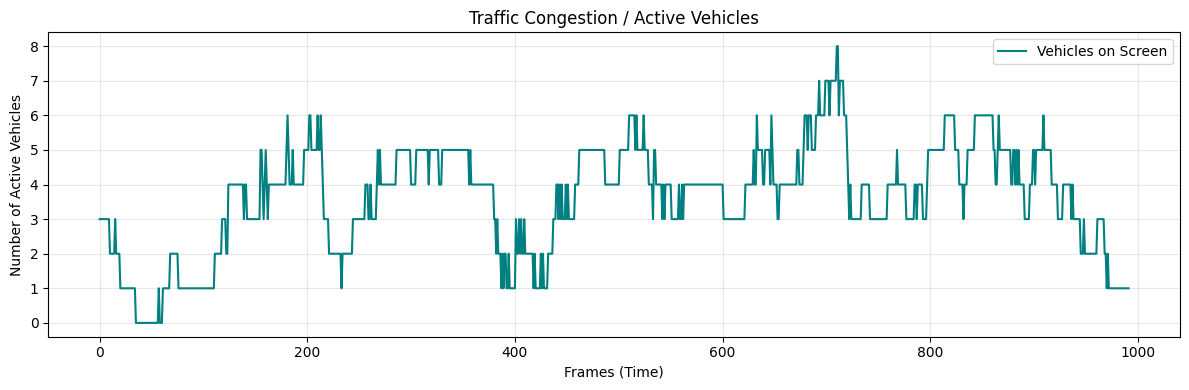


✅ Processing Complete! You can now download:
 1. Video  -> output_analytics.mp4 (From Colab sidebar)
 2. Data   -> traffic_data.csv
 3. Chart  -> analytics_congestion.png


In [15]:
out.release()
cap.release()
csv_file.close()

print('\n' + '='*50)
print(' FINAL ANALYTICS SUMMARY')
print('='*50)
print(f' Total Frames      : {frame_count}')
print(f' Vehicles Entered  : {tracker.entries}')
print(f' Vehicles Exited   : {tracker.exits}')
print(f' Total Unique Cars : {tracker.next_id}')

    # Calculate average and max time spent on screen
if tracker.completed_dwells:
        avg_dwell = np.mean(tracker.completed_dwells) / FPS_ASSUMED
        max_dwell = np.max(tracker.completed_dwells) / FPS_ASSUMED
        print(f' Avg Dwell Time    : {avg_dwell:.2f} seconds')
        print(f' Max Dwell Time    : {max_dwell:.2f} seconds')
print('='*50)

    # Generate a beautiful chart showing how busy the road was over time
plt.figure(figsize=(12, 4))
plt.plot(obj_count_history, color='teal', label='Vehicles on Screen')
plt.title('Traffic Congestion / Active Vehicles')
plt.xlabel('Frames (Time)')
plt.ylabel('Number of Active Vehicles')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('analytics_congestion.png', dpi=120)
plt.show()

print("\n✅ Processing Complete! You can now download:")
print(" 1. Video  -> output_analytics.mp4 (From Colab sidebar)")
print(" 2. Data   -> traffic_data.csv")
print(" 3. Chart  -> analytics_congestion.png")